In [1]:
# Model Creation
import pandas as pd
# Load dataset
df = pd.read_csv("../data/phone_usage_india.csv")

# Remove User ID
df = df.drop("User ID", axis=1)

# Features and Target
X = df.drop("Primary Use", axis=1)
y = df["Primary Use"]

# Encode target
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

# Encode categorical features
X = pd.get_dummies(
    X,
    columns=["Gender", "Location", "Phone Brand", "OS"],
    drop_first=True
)

# Train Test Split
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


1. Logistics Regression Model

In [2]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_model.fit(x_train, y_train)

# Prediction
y_pred = log_model.predict(x_test)

print(y_pred[:10])

[1 2 4 4 1 0 1 4 1 0]


c:\Users\rao27\Desktop\PhoneUse_Pattern\env\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [3]:
# Model Evaluation
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

logistic_accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy :{logistic_accuracy:.4f}")

conf_matrix = confusion_matrix(y_test, y_pred)
print(f"Confusion Matrix: \n{conf_matrix}")

class_report = classification_report(y_test, y_pred)
print(f"Classification Report: \n{class_report}")

Accuracy :0.1976
Confusion Matrix: 
[[214  88 159  10 255]
 [221 109 146   5 216]
 [225 125 134  10 215]
 [222  97 150   7 250]
 [219  86 131   9 235]]
Classification Report: 
              precision    recall  f1-score   support

           0       0.19      0.29      0.23       726
           1       0.22      0.16      0.18       697
           2       0.19      0.19      0.19       709
           3       0.17      0.01      0.02       726
           4       0.20      0.35      0.25       680

    accuracy                           0.20      3538
   macro avg       0.19      0.20      0.18      3538
weighted avg       0.19      0.20      0.17      3538



In [4]:
import pickle
with open("../models/logistic_regression.pkl", "wb") as file:
    pickle.dump(log_model, file)

print("Logistic Regression Model saved successfully!")

Logistic Regression Model saved successfully!


In [15]:
import os
import pickle as pkl

os.makedirs("models", exist_ok=True)
with open("models/scaler.pkl", "wb") as file:
    pkl.dump(scaler, file)
print("Scaler saved successfully!")    

NameError: name 'scaler' is not defined

In [5]:
import pickle

with open("../models/label_encoder.pkl", "wb") as file:
    pickle.dump(label_encoder, file)

print("Label Encoder saved successfully!")

Label Encoder saved successfully!


In [6]:
import os
print(os.listdir("../models"))

['decision_tree_model.pkl', 'feature_columns.pkl', 'label_encoder.pkl', 'lighgb_model.pkl', 'logistic_regression.pkl', 'random_forest_model.pkl', 'scaler.pkl', 'xgboost_model.pkl']


2. Decision Tree Model

In [7]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    criterion="gini",
    random_state=42,
    max_depth=4
)

# Train the model
dt_model.fit(x_train, y_train)

#Predict model

y_dt_pred = dt_model.predict(x_test)
print(y_dt_pred[:10])

[4 3 4 4 2 4 4 3 2 3]


DT Evaluation

In [8]:
# Accuracy Score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

dt_accuracy = accuracy_score(y_test, y_dt_pred)
print("Decision Tree Accuracy:", dt_accuracy)

print("Classificatio Report:\n", classification_report(y_test, y_dt_pred))

cm = confusion_matrix(y_test, y_dt_pred)
print("Confusion Matrix:\n", cm)



Decision Tree Accuracy: 0.1978518937252685
Classificatio Report:
               precision    recall  f1-score   support

           0       0.16      0.01      0.02       726
           1       0.00      0.00      0.00       697
           2       0.22      0.30      0.25       709
           3       0.18      0.09      0.12       726
           4       0.19      0.61      0.29       680

    accuracy                           0.20      3538
   macro avg       0.15      0.20      0.14      3538
weighted avg       0.15      0.20      0.14      3538

Confusion Matrix:
 [[  8   0 209  70 439]
 [ 10   0 183  73 431]
 [ 10   0 211  84 404]
 [ 13   1 189  65 458]
 [ 10   1 186  67 416]]


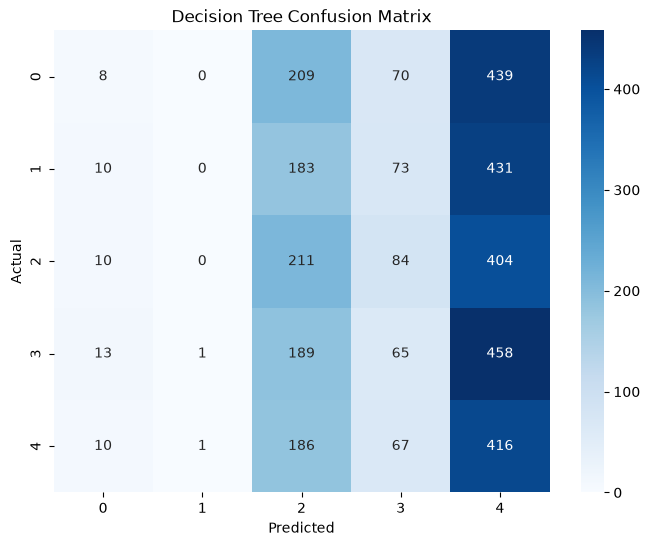

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt = "d",
    cmap = "Blues"
    )

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [10]:
import pickle
with open("../models/decision_tree_model.pkl", "wb") as file:
    pickle.dump(dt_model, file)

print("Decision Tree Model saved successfully!")

Decision Tree Model saved successfully!


In [11]:
import os
print(os.listdir("../models"))

['decision_tree_model.pkl', 'feature_columns.pkl', 'label_encoder.pkl', 'lighgb_model.pkl', 'logistic_regression.pkl', 'random_forest_model.pkl', 'scaler.pkl', 'xgboost_model.pkl']


Random Forest

In [12]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(x_train, y_train)
print(rf_model)

# Predict RF model
y_pred_rf = rf_model.predict(x_test)
print("Predictions:", y_pred_rf[:10])
print("EncodedPredicted Labels:", label_encoder.inverse_transform(y_pred_rf[:10]))
print("Actual Values:", y_test[:10])
print("Encoded Actual Labels:", label_encoder.inverse_transform(y_test[:10]))

RandomForestClassifier(random_state=42)
Predictions: [1 4 0 3 2 2 2 1 0 2]
EncodedPredicted Labels: ['Entertainment' 'Work' 'Education' 'Social Media' 'Gaming' 'Gaming'
 'Gaming' 'Entertainment' 'Education' 'Gaming']
Actual Values: [4 1 3 1 3 3 2 2 4 2]
Encoded Actual Labels: ['Work' 'Entertainment' 'Social Media' 'Entertainment' 'Social Media'
 'Social Media' 'Gaming' 'Gaming' 'Work' 'Gaming']


Random Forest Evolution

In [13]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {rf_accuracy:.4f}")

print("Classification Report:\n", classification_report(y_test, y_pred_rf))

cm_rf = confusion_matrix(y_test, y_pred_rf)
print(f"Confusion Matrix:\n{cm_rf}")

Random Forest Accuracy: 0.1984
Classification Report:
               precision    recall  f1-score   support

           0       0.21      0.23      0.22       726
           1       0.21      0.20      0.20       697
           2       0.18      0.20      0.19       709
           3       0.21      0.18      0.20       726
           4       0.18      0.18      0.18       680

    accuracy                           0.20      3538
   macro avg       0.20      0.20      0.20      3538
weighted avg       0.20      0.20      0.20      3538

Confusion Matrix:
[[170 123 165 130 138]
 [161 140 169 106 121]
 [141 140 139 137 152]
 [178 131 154 133 130]
 [146 137 149 128 120]]


RF Confusion Matrix HeatMap

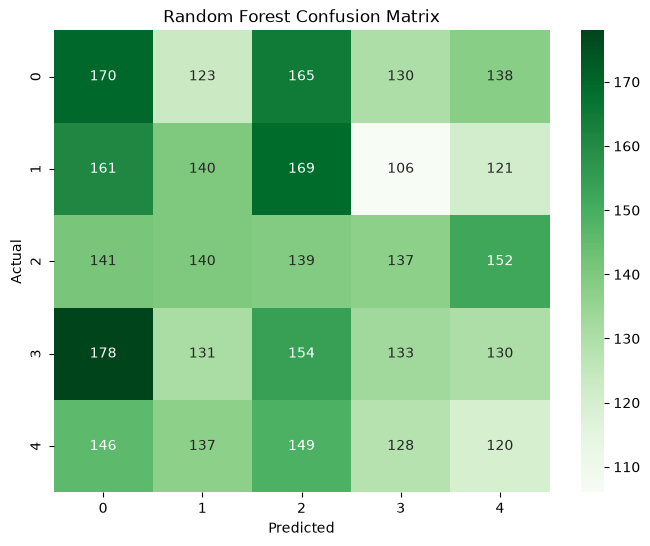

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Save RF model

In [15]:
import pickle as pkl
with open("../models/random_forest_model.pkl", "wb") as file:
    pkl.dump(rf_model, file)
print("Random Forest Model saved Successfully!")    

Random Forest Model saved Successfully!


XGBoost (Extreme Gradient Boost) Model 

In [17]:
from xgboost import XGBClassifier
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)
xgb_model.fit(x_train, y_train)

y_pred_xgb = xgb_model.predict(x_test)
print("Predictions:", y_pred_xgb[:10])
print("Actual Value:", y_test[:10])

print(label_encoder.inverse_transform(y_pred_xgb[:10]))
print(label_encoder.inverse_transform(y_test[:10]))

Predictions: [2 2 2 1 2 2 2 0 0 3]
Actual Value: [4 1 3 1 3 3 2 2 4 2]
['Gaming' 'Gaming' 'Gaming' 'Entertainment' 'Gaming' 'Gaming' 'Gaming'
 'Education' 'Education' 'Social Media']
['Work' 'Entertainment' 'Social Media' 'Entertainment' 'Social Media'
 'Social Media' 'Gaming' 'Gaming' 'Work' 'Gaming']


XGBoost Model Evolution

In [18]:
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
print(f"XGBoost Acuracy {xgb_accuracy:.4f}:")

print(f"Classification Report\n {classification_report(y_test, y_pred_xgb)}")

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
print("XGBoost Confusion Matrix:\n",cm_xgb)

XGBoost Acuracy 0.2027:
Classification Report
               precision    recall  f1-score   support

           0       0.22      0.21      0.21       726
           1       0.19      0.19      0.19       697
           2       0.21      0.22      0.21       709
           3       0.22      0.19      0.20       726
           4       0.19      0.21      0.20       680

    accuracy                           0.20      3538
   macro avg       0.20      0.20      0.20      3538
weighted avg       0.20      0.20      0.20      3538

XGBoost Confusion Matrix:
 [[151 136 159 126 154]
 [131 130 147 121 168]
 [150 130 154 121 154]
 [146 145 149 137 149]
 [117 153 136 129 145]]


XGBoost Confusion Model HeatMap

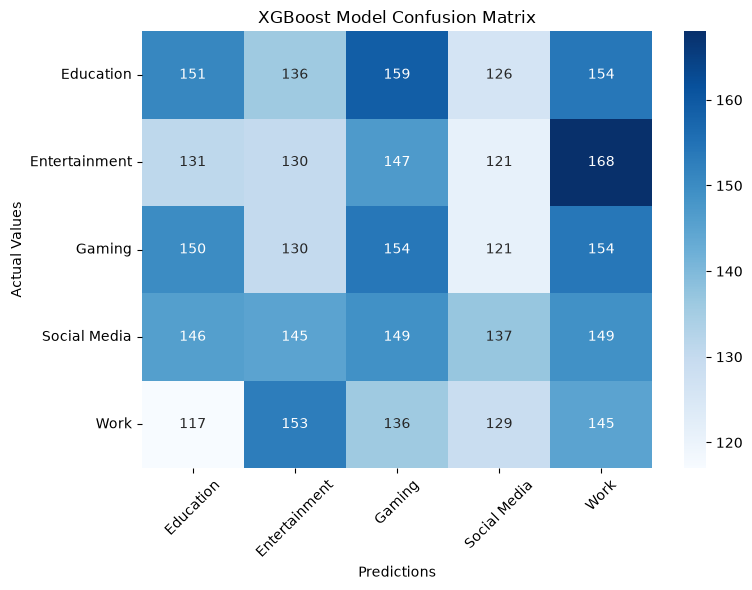

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(
    cm_xgb,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("XGBoost Model Confusion Matrix")
plt.xlabel("Predictions")
plt.ylabel("Actual Values")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()

plt.show()

Save XGBoost Model

In [20]:
import pickle as pkl
with open("../models/xgboost_model.pkl", "wb") as file:
    pkl.dump(xgb_model, file)

print("XGBoost Model saved successfully!")    

XGBoost Model saved successfully!


LightGB Model

In [21]:
from lightgbm import LGBMClassifier

lgbm_model = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
    #num_leaves=31
)

lgbm_model.fit(x_train, y_train)
y_pred_lgbm = lgbm_model.predict(x_test)

print("Prediction:",y_pred_lgbm[:10])
print("Actual Values:", y_test[:10])



[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001021 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1590
[LightGBM] [Info] Number of data points in the train set: 14148, number of used features: 31
[LightGBM] [Info] Start training from score -1.593521
[LightGBM] [Info] Start training from score -1.636519
[LightGBM] [Info] Start training from score -1.596307
[LightGBM] [Info] Start training from score -1.628923
[LightGBM] [Info] Start training from score -1.592825
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

LightGB Model Evaluation

In [22]:
lgbm_accuracy = accuracy_score(y_test, y_pred_lgbm)
print("LGB Model Accuracy",lgbm_accuracy)

print("Classification Report:\n", classification_report(y_test, y_pred_lgbm))

cm_lgbm = confusion_matrix(y_test, y_pred_lgbm)
print("LGB Model Confusion Matrix:\n", cm_lgbm)

LGB Model Accuracy 0.1933295647258338
Classification Report:
               precision    recall  f1-score   support

           0       0.19      0.17      0.18       726
           1       0.19      0.19      0.19       697
           2       0.21      0.21      0.21       709
           3       0.21      0.20      0.21       726
           4       0.17      0.19      0.18       680

    accuracy                           0.19      3538
   macro avg       0.19      0.19      0.19      3538
weighted avg       0.19      0.19      0.19      3538

LGB Model Confusion Matrix:
 [[124 132 167 151 152]
 [135 135 145 122 160]
 [142 134 149 129 155]
 [133 148 134 145 166]
 [122 156 131 140 131]]


Save LighGB Model

In [23]:
import pickle as pkl
with open("../models/lighgb_model.pkl", "wb") as file:
    pkl.dump(lgbm_model, file)

print("LightGB Model saved successfully!")    

LightGB Model saved successfully!


LightGB Model Confusion Matrix HeatMap

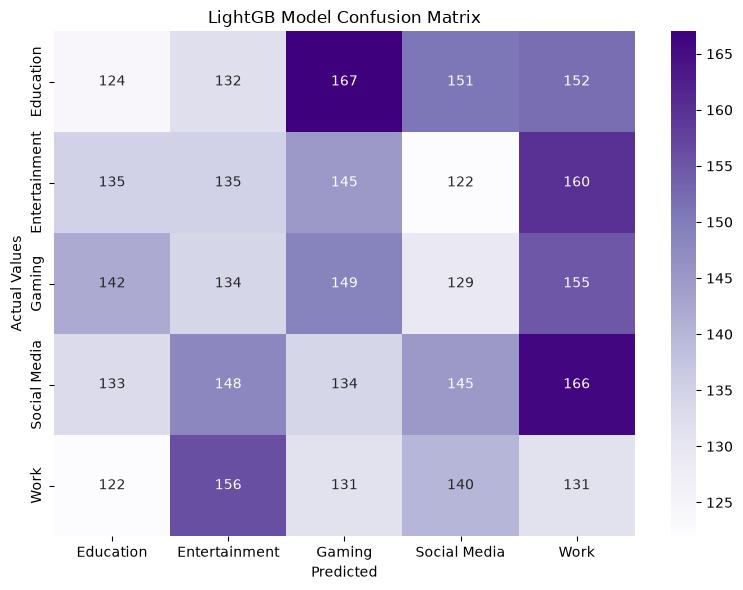

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(
    cm_lgbm,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("LightGB Model Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual Values")

plt.tight_layout()
plt.show()

Comapres all Models

In [25]:
print("Model Comaprision")
print("_" * 40)

print(f"Logistic Regression : {logistic_accuracy:.4f}")
print(f"Decision Tree : {dt_accuracy :.4f}")
print(f"Random Forest : {rf_accuracy :.4f}")
print(f"XGBoost : {xgb_accuracy      :.4f}")
print(f"LighGBM :{lgbm_accuracy      :.4f}")

Model Comaprision
________________________________________
Logistic Regression : 0.1976
Decision Tree : 0.1979
Random Forest : 0.1984
XGBoost : 0.2027
LighGBM :0.1933


Features Importance Analysis

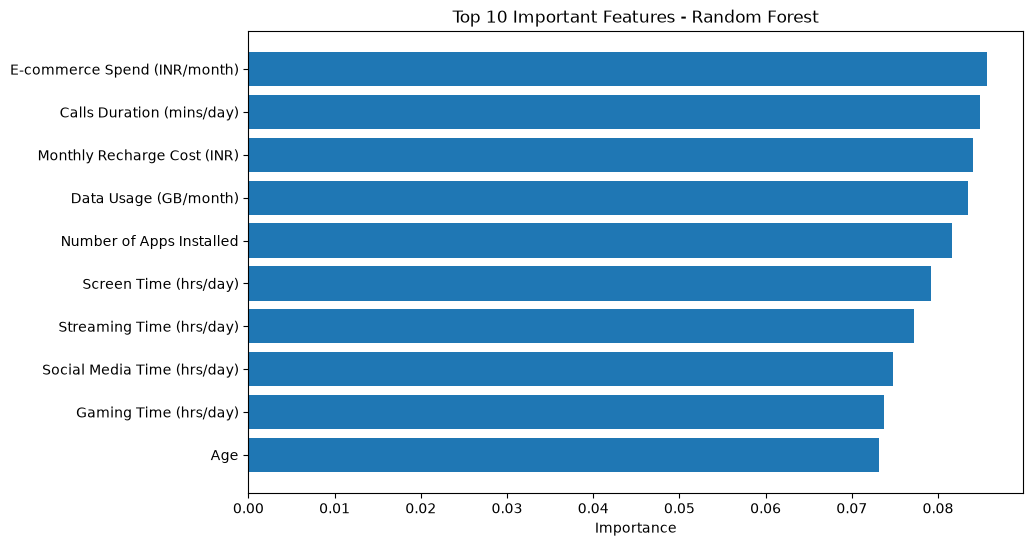

In [27]:
#Random Forest Feature Importance

import matplotlib.pyplot as plt
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": x_train.columns,
    "Importance": rf_model.feature_importances_
})

# Sort Values
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Top 10 features
top_features = feature_importance.head(10)

# Plot
plt.figure(figsize=(10,6))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.xlabel("Importance")
plt.title("Top 10 Important Features - Random Forest")
plt.gca().invert_yaxis()
plt.show()

XGBoost Feature Importance

<Figure size 1000x800 with 0 Axes>

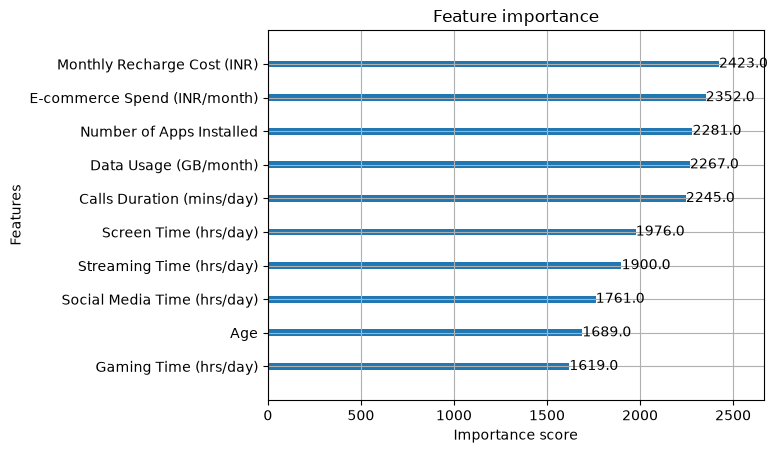

In [28]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
plot_importance(xgb_model, max_num_features=10)

plt.show()


LightGBM Feature Importance

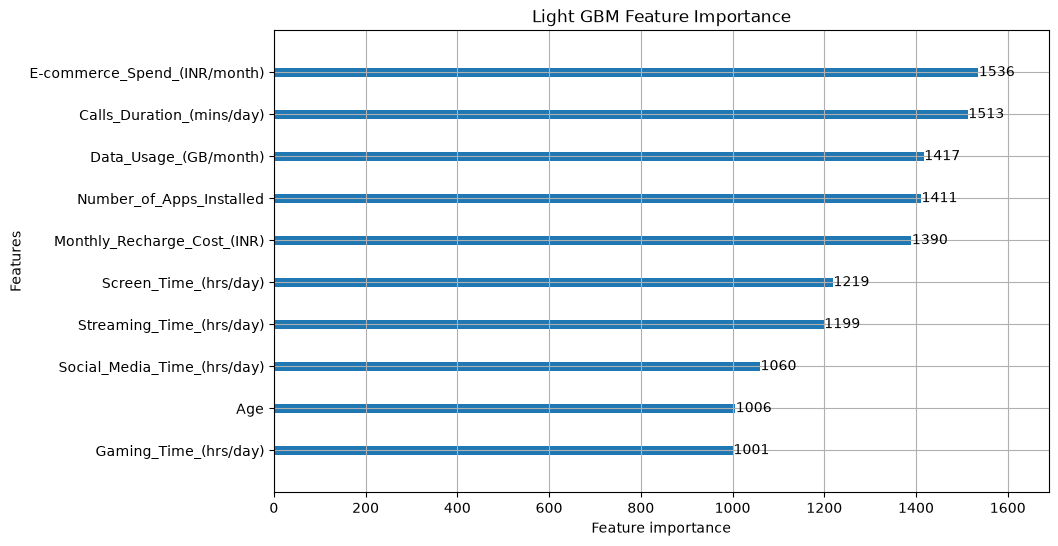

In [29]:
import lightgbm as lgb
lgb.plot_importance(
    lgbm_model,
    max_num_features=10,
    figsize=(10,6)
)

plt.title("Light GBM Feature Importance")
plt.show()